In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pickle
import os

In [51]:
class SwinehartAbbottNetworkOneLayer(nn.Module):
    def __init__(self, input_size, output_size, init_gain, init_shift, init_weight, connect_prob=0.9):
        super(SwinehartAbbottNetworkOneLayer, self).__init__()
        self.input_size = input_size
        #self.gain = nn.Parameter(torch.tensor(init_gain, dtype=torch.float32))
        #self.shift = nn.Parameter(torch.tensor(init_shift, dtype=torch.float32))
        #self.weights = nn.Parameter(torch.tensor(init_weight, dtype=torch.float32))

        self.gain = torch.tensor(init_gain, requires_grad=True, dtype=torch.float32)
        self.shift = torch.tensor(init_shift, requires_grad=True, dtype=torch.float32)
        self.weights = torch.tensor(init_weight, requires_grad=True, dtype=torch.float32)

        self.wiring_mask = torch.from_numpy(np.random.choice([1, 0], size =(output_size, input_size), p=[connect_prob, 1-connect_prob]))

        self.activation_func = nn.Sigmoid()
        self.output_gain = torch.tensor(3, requires_grad=True, dtype=torch.float32) # 3
        self.output_shift = torch.tensor(1, requires_grad=True, dtype=torch.float32) # 1


    
    def normal_pdf(self, theta):
        return 1.5 * torch.exp(-(theta ** 2)/2) - 0.5
    

    def gaussian_rf(self, x):
        theta_is = torch.linspace(0, 2 * torch.pi, self.input_size).view(-1,1)
        return self.normal_pdf(x-theta_is) + self.normal_pdf(x-theta_is+2*torch.pi) + self.normal_pdf(x-theta_is-2*torch.pi)

    def forward(self, x):

        x = self.gaussian_rf(x)
        self.input_activations = x.clone()

        x = self.activation_func(self.gain * (x - self.shift))
        self.hidden_activations = x.clone()


        readout_mat = torch.mul(self.weights, self.wiring_mask) # elementwise multiplication with binary mask
        x = torch.matmul(readout_mat, x)
        x = self.activation_func(self.output_gain * (x - self.output_shift))
        self.output_activations = x.clone()

        return x

### Two Output Node Simulation

In [72]:
output_size = 2

input_size = 230
hebb_alpha = int(input_size * 0.45) 

init_gain = 3 * np.ones((input_size, 1))
init_shift = 1 * np.ones((input_size, 1))
init_weight = np.ones((output_size, input_size)) 
init_weight /= np.sum(init_weight, axis=1, keepdims=True)
init_weight *= hebb_alpha

torch.manual_seed(42)

# Data Generation, we will generate data points between 0 and 2*pi
ndata = 50
xs = torch.linspace(0, 2 * torch.pi, ndata)

target_output_1 = torch.cos(xs)/4 + 0.5
target_output_2 = torch.cos(xs - (np.pi/2) )/4 + 0.5


# training loop
num_epochs = 600
num_train_data = ndata*num_epochs 

controller_lr = 0.8 #0.2
hebbian_lr = 0.03

has_controller = True
has_hebbian = True


# establish model
model = SwinehartAbbottNetworkOneLayer(input_size, output_size, init_gain, init_shift, init_weight)
loss_func = nn.MSELoss()
optimizer = optim.SGD([model.gain, model.shift], lr=controller_lr)
#optimizer = optim.SGD([model.gain, model.shift, model.output_gain, model.output_shift], lr=controller_lr)


# Things to track
rc_losses = np.zeros(num_train_data+1)
#rc_outputs =  np.zeros(num_train_data)
rc_gains = np.zeros((input_size, num_train_data+1))
rc_shifts = np.zeros((input_size, num_train_data+1))
rc_weights = np.zeros((output_size, input_size, num_train_data+1))
rc_activations = np.zeros((input_size, num_train_data+1))


check_rf_every = 100
num_rc_rfs = int(np.ceil(num_train_data/check_rf_every))
rc_receptive_fields = np.zeros((input_size, ndata, num_rc_rfs))
rc_rfs_weights = np.zeros((output_size, input_size, num_rc_rfs))
rc_rfs_outputs = np.zeros((output_size, ndata, num_rc_rfs))



rc_gains[:, 0] = model.gain.detach().numpy().squeeze()
rc_shifts[:, 0] = model.shift.detach().numpy().squeeze()
rc_weights[:,:, 0] = model.weights.detach().numpy().squeeze()

In [73]:
rc_ind = 1
rc_rf_ind = 0
for epoch in range(num_epochs):

    # shuffle data
    perm_idx = np.arange(ndata) #torch.randperm(ndata)
    shuffled_xs = xs[perm_idx]
    shuffled_target_1 = target_output_1[perm_idx]
    shuffled_target_2 = target_output_2[perm_idx]

    epoch_loss = 0

    # forward
    for samp_ind in np.arange(ndata):

        x = shuffled_xs[samp_ind]
        target1 = shuffled_target_1[samp_ind]
        target2 = shuffled_target_2[samp_ind]
        target = torch.tensor([target1, target2], dtype=torch.float32)


        # forward   
        output_activations = model(x)
        output = output_activations.squeeze()

        # Calculate loss
        loss = 0.5 * loss_func(output, target)
        epoch_loss += loss

        # backprop for gains and shifts
        if has_controller:

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


        # hebbian learning for weights
        if has_hebbian:

            hebbian_update = model.output_activations * (model.hidden_activations).T
            with torch.no_grad():
                model.weights += hebbian_lr * hebbian_update
                model.weights /= torch.sum(model.weights, dim=1, keepdim=True)
                model.weights *= hebb_alpha


        # Record responses
        rc_gains[:, rc_ind] = model.gain.detach().numpy().squeeze()
        rc_shifts[:, rc_ind] = model.shift.detach().numpy().squeeze()
        rc_weights[:,:, rc_ind] = model.weights.detach().numpy().squeeze()
        rc_activations[:, epoch+1] = model.input_activations.detach().numpy().squeeze()
        rc_losses[rc_ind] = epoch_loss.item()

        if rc_ind % check_rf_every == 0:
            with torch.no_grad():
                for i, x in enumerate(xs):
                    interm_outputs = model(x)
                    hidden_acts = model.hidden_activations.detach().numpy().squeeze()
                    rc_receptive_fields[:, i, rc_rf_ind] = hidden_acts
                rc_rfs_weights[:, :, rc_rf_ind] = model.weights.detach().numpy().squeeze()
                rc_rfs_outputs[:, :, rc_rf_ind] = model(xs).detach().numpy().squeeze()

                rc_rf_ind += 1
            
        rc_ind += 1


    # print losses
    epoch_loss /= ndata
    if (epoch + 1) % 10 == 0:
        gain_change = np.sum(np.abs(rc_gains[:, epoch] - rc_gains[:, epoch-1]))
        shift_change = np.sum(np.abs(rc_shifts[:, epoch] - rc_shifts[:, epoch-1]))
        weight_change = np.sum(np.abs(rc_weights[:,:, epoch] - rc_weights[:,:, epoch-1]))

        print(f"Epoch: {epoch}, Loss: {epoch_loss}, gain change: {gain_change}, shift change: {shift_change}, weight change: {weight_change}")




Epoch: 9, Loss: 0.003695657942444086, gain change: 0.09700226783752441, shift change: 0.23927444219589233, weight change: 0.09338751435279846
Epoch: 19, Loss: 0.00048530290951021016, gain change: 0.01700282096862793, shift change: 0.04209071397781372, weight change: 0.0865069031715393
Epoch: 29, Loss: 0.0002772282750811428, gain change: 0.10583639144897461, shift change: 0.25301772356033325, weight change: 0.07315537333488464
Epoch: 39, Loss: 0.0001960473309736699, gain change: 0.05167865753173828, shift change: 0.12278294563293457, weight change: 0.07075875997543335
Epoch: 49, Loss: 0.00015095325943548232, gain change: 0.04892921447753906, shift change: 0.1211736798286438, weight change: 0.09811797738075256
Epoch: 59, Loss: 0.00011947948223678395, gain change: 0.046190738677978516, shift change: 0.11734771728515625, weight change: 0.11595886945724487
Epoch: 69, Loss: 9.930101077770814e-05, gain change: 0.015904903411865234, shift change: 0.039678990840911865, weight change: 0.08201688

### Results

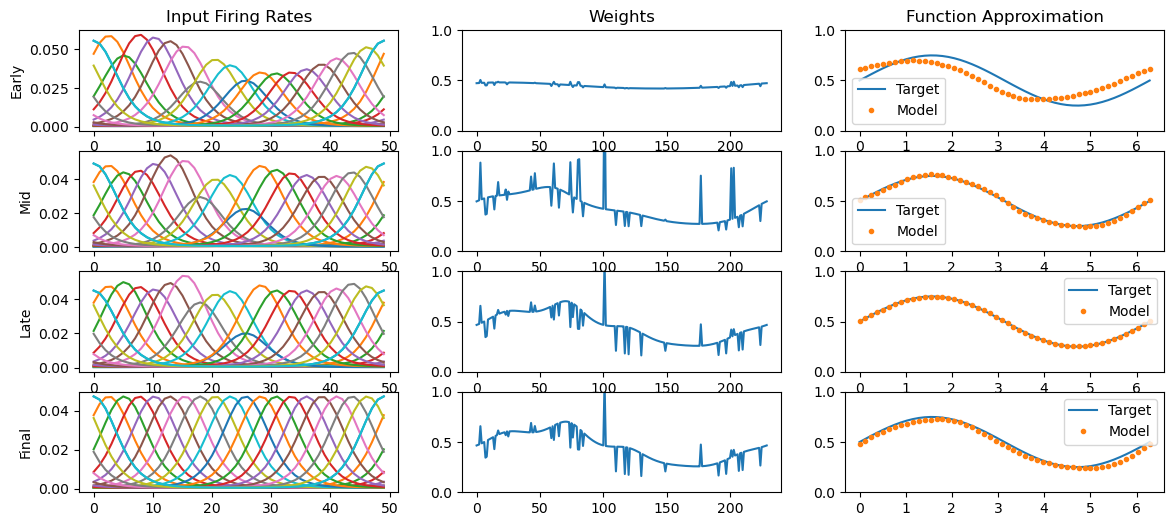

In [74]:
#  set time points to check values
early_ind = int(num_rc_rfs*0.01)
mid_ind = int(num_rc_rfs*0.15)
late_ind = int(num_rc_rfs*0.95)

out_ind = 1
ys = target_output_2

# randomly sample the units
num_units_sample = 20
samp_inds = np.linspace(0, input_size-1, num_units_sample).astype(int)

# EARLY TRAINING ---------------------

plt.figure(figsize=(14, 6))
plt.subplot(4,3,1)
vals = rc_receptive_fields[samp_inds, :, early_ind].T
plt.plot(vals);
#plt.ylim([0, 0.06])
plt.ylabel("Early")
plt.title("Input Firing Rates")

plt.subplot(4,3,2)
plt.plot(rc_rfs_weights[out_ind, :,early_ind]);
plt.ylim([0, 1])
plt.title("Weights")

plt.subplot(4,3,3)
plt.plot(xs, ys, label="Target")
plt.plot(xs, rc_rfs_outputs[out_ind, :,early_ind], '.',label="Model")
plt.title("Function Approximation")
plt.ylim([0, 1])
plt.legend()
 
# MID TRAINING ---------------------

plt.subplot(4,3,4)
vals = rc_receptive_fields[samp_inds, :, mid_ind].T
plt.plot(vals);
#plt.ylim([0, 0.06])
plt.ylabel("Mid")

plt.subplot(4,3,5)
plt.plot(rc_rfs_weights[out_ind, :,mid_ind]);
plt.ylim([0, 1])

plt.subplot(4,3,6)
plt.plot(xs, ys, label="Target")
plt.plot(xs, rc_rfs_outputs[out_ind, :,mid_ind], '.',label="Model")
plt.ylim([0, 1])
plt.legend()

# LATE TRAINING ---------------------

plt.subplot(4,3,7)
vals = rc_receptive_fields[samp_inds, :, late_ind].T
plt.plot(vals);
#plt.ylim([0, 0.06])
plt.ylabel("Late")

plt.subplot(4,3,8)
plt.plot(rc_rfs_weights[out_ind, :,late_ind]);
plt.ylim([0, 1])

plt.subplot(4,3,9)
plt.plot(xs, ys, label="Target")
plt.plot(xs, (rc_rfs_outputs[out_ind,:,late_ind]), '.',label="Model")
plt.ylim([0, 1])
plt.legend()



# POST TRAINING ---------------------
final_weights = model.weights.detach().numpy().squeeze()
new_model = SwinehartAbbottNetworkOneLayer(input_size, output_size, init_gain, init_shift, final_weights)
final_outputs = new_model(xs).detach().numpy().squeeze()
final_rfs = np.zeros((input_size, ndata))

for i, x in enumerate(xs):
    interm_outputs = new_model(x)
    final_rfs[:, i] = new_model.hidden_activations.detach().numpy().squeeze()


plt.subplot(4,3,10)
vals = final_rfs[samp_inds, :].T
plt.plot(vals);
#plt.ylim([0, 0.06])
plt.ylabel("Final")

plt.subplot(4,3,11)
plt.plot(final_weights[out_ind, :]);
plt.ylim([0, 1])

plt.subplot(4,3,12)
plt.plot(xs, ys, label="Target")
plt.plot(xs, final_outputs[out_ind, :], '.',label="Model")
plt.ylim([0, 1])
plt.legend()


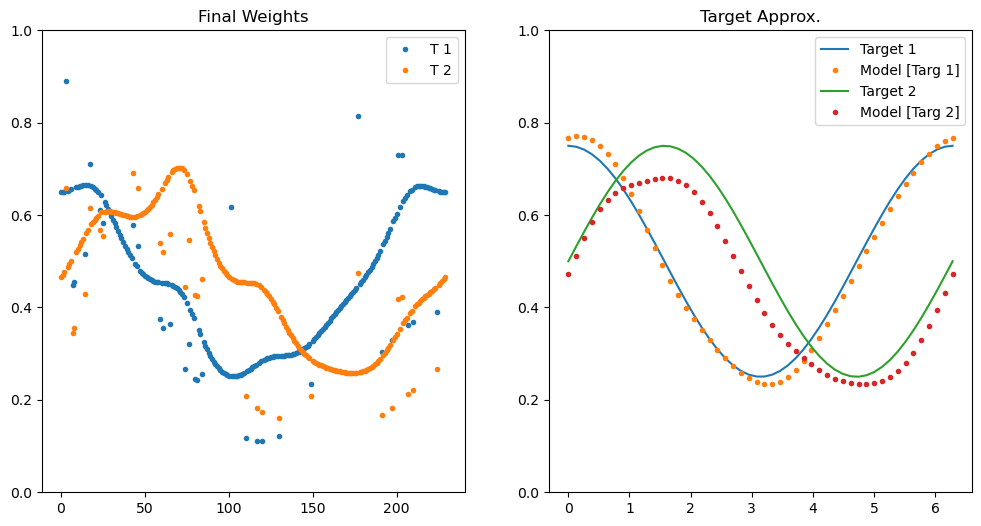

In [75]:
# POST TRAINING ---------------------
final_weights = model.weights.detach().numpy().squeeze()
new_model = SwinehartAbbottNetworkOneLayer(input_size, output_size, init_gain, init_shift, final_weights)
final_outputs = new_model(xs).detach().numpy().squeeze()


# Weights
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
out_ind = 0
plt.plot(final_weights[out_ind, :], '.',label=f"T {out_ind+1}")
out_ind = 1
plt.plot(final_weights[out_ind, :], '.',label=f"T {out_ind+1}")
plt.title("Final Weights")
plt.ylim([0, 1])
plt.legend()


# Targ Approx

plt.subplot(1,2,2)
out_ind = 0
plt.plot(xs, target_output_1, label=f"Target {out_ind+1}")
plt.plot(xs, final_outputs[out_ind, :], '.',label=f"Model [Targ {out_ind+1}]")
plt.ylim([0, 1])

out_ind = 1
plt.plot(xs, target_output_2, label=f"Target {out_ind+1}")
plt.plot(xs, final_outputs[out_ind, :], '.',label=f"Model [Targ {out_ind+1}]")
plt.ylim([0, 1])

plt.title("Target Approx.")
plt.legend()



# Multi Output Node Simulation

In [114]:
output_size = 20
conProb = 0.9 


input_size = 230
hebb_alpha = int(input_size * 0.45) 

init_gain = 3 * np.ones((input_size, 1))
init_shift = 1 * np.ones((input_size, 1))
init_weight = np.ones((output_size, input_size)) 
init_weight /= np.sum(init_weight, axis=1, keepdims=True)
init_weight *= hebb_alpha

torch.manual_seed(42)

# Data Generation: Make the target outputs many shifted cosines
ndata = 50
xs = torch.linspace(0, 2 * torch.pi, ndata)

output_targ_shifts = torch.linspace(0, 2 * torch.pi, output_size)
target_outputs = torch.zeros((output_size, ndata))
for ind, shift in enumerate(output_targ_shifts):
    target_outputs[ind,:] = torch.cos(xs - shift)/4 + 0.5



# training loop
num_epochs = 2000
num_train_data = ndata*num_epochs 

controller_lr = 0.8 #0.2
hebbian_lr = 0.3

has_controller = True
has_hebbian = True


# establish model
MultiModel = SwinehartAbbottNetworkOneLayer(input_size, output_size, init_gain, init_shift, init_weight, connect_prob=conProb)
loss_func = nn.MSELoss()
optimizer = optim.SGD([MultiModel.gain, MultiModel.shift], lr=controller_lr)
#optimizer = optim.SGD([model.gain, model.shift, model.output_gain, model.output_shift], lr=controller_lr)


# Things to track
rc_losses = np.zeros(num_train_data+1)
#rc_outputs =  np.zeros(num_train_data)
rc_gains = np.zeros((input_size, num_train_data+1))
rc_shifts = np.zeros((input_size, num_train_data+1))
rc_weights = np.zeros((output_size, input_size, num_train_data+1))
rc_activations = np.zeros((input_size, num_train_data+1))


check_rf_every = 100
num_rc_rfs = int(np.ceil(num_train_data/check_rf_every))
rc_receptive_fields = np.zeros((input_size, ndata, num_rc_rfs))
rc_rfs_weights = np.zeros((output_size, input_size, num_rc_rfs))
rc_rfs_outputs = np.zeros((output_size, ndata, num_rc_rfs))



rc_gains[:, 0] = MultiModel.gain.detach().numpy().squeeze()
rc_shifts[:, 0] = MultiModel.shift.detach().numpy().squeeze()
rc_weights[:,:, 0] = MultiModel.weights.detach().numpy().squeeze()

In [115]:
rc_ind = 1
rc_rf_ind = 0

for epoch in range(num_epochs):

    # shuffle data
    perm_idx = np.arange(ndata) #torch.randperm(ndata)
    shuffled_xs = xs[perm_idx]
    shuffled_targets = target_outputs[:, perm_idx]

    epoch_loss = 0

    # forward
    for samp_ind in np.arange(ndata):

        x = shuffled_xs[samp_ind]        
        target = shuffled_targets[:, samp_ind]


        # forward   
        output_activations = MultiModel(x)
        output = output_activations.squeeze()

        # Calculate loss
        loss = 0.5 * loss_func(output, target)
        epoch_loss += loss

        # backprop for gains and shifts
        if has_controller:

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


        # hebbian learning for weights
        if has_hebbian:

            hebbian_update = MultiModel.output_activations * (MultiModel.hidden_activations).T
            with torch.no_grad():
                MultiModel.weights += hebbian_lr * hebbian_update
                MultiModel.weights /= torch.sum(MultiModel.weights, dim=1, keepdim=True)
                MultiModel.weights *= hebb_alpha


        # Record responses
        rc_gains[:, rc_ind] = MultiModel.gain.detach().numpy().squeeze()
        rc_shifts[:, rc_ind] = MultiModel.shift.detach().numpy().squeeze()
        rc_weights[:,:, rc_ind] = MultiModel.weights.detach().numpy().squeeze()
        rc_activations[:, epoch+1] = MultiModel.input_activations.detach().numpy().squeeze()
        rc_losses[rc_ind] = epoch_loss.item()

        if rc_ind % check_rf_every == 0:
            with torch.no_grad():
                for i, x in enumerate(xs):
                    interm_outputs = MultiModel(x)
                    hidden_acts = MultiModel.hidden_activations.detach().numpy().squeeze()
                    rc_receptive_fields[:, i, rc_rf_ind] = hidden_acts
                rc_rfs_weights[:, :, rc_rf_ind] = MultiModel.weights.detach().numpy().squeeze()
                rc_rfs_outputs[:, :, rc_rf_ind] = MultiModel(xs).detach().numpy().squeeze()

                rc_rf_ind += 1
            
        rc_ind += 1


    # print losses
    epoch_loss /= ndata
    if (epoch + 1) % 10 == 0:
        gain_change = np.sum(np.abs(rc_gains[:, epoch] - rc_gains[:, epoch-1]))
        shift_change = np.sum(np.abs(rc_shifts[:, epoch] - rc_shifts[:, epoch-1]))
        weight_change = np.sum(np.abs(rc_weights[:,:, epoch] - rc_weights[:,:, epoch-1]))

        print(f"Epoch: {epoch}, Loss: {epoch_loss}, gain change: {gain_change}, shift change: {shift_change}, weight change: {weight_change}")




Epoch: 9, Loss: 0.015547225251793861, gain change: 0.01179647445678711, shift change: 0.028211534023284912, weight change: 7.766982406377792
Epoch: 19, Loss: 0.013227755203843117, gain change: 0.006598472595214844, shift change: 0.015505671501159668, weight change: 7.826836496591568
Epoch: 29, Loss: 0.01049348246306181, gain change: 0.012296676635742188, shift change: 0.0297468900680542, weight change: 7.6770100593566895
Epoch: 39, Loss: 0.00820858683437109, gain change: 0.027472496032714844, shift change: 0.06611639261245728, weight change: 7.6665021777153015
Epoch: 49, Loss: 0.0063803549855947495, gain change: 0.009624719619750977, shift change: 0.023365676403045654, weight change: 8.417704343795776
Epoch: 59, Loss: 0.005014713387936354, gain change: 0.008585453033447266, shift change: 0.020490050315856934, weight change: 7.938480466604233
Epoch: 69, Loss: 0.004045367706567049, gain change: 0.006720066070556641, shift change: 0.01580226421356201, weight change: 7.905381679534912
Epoc

### Results

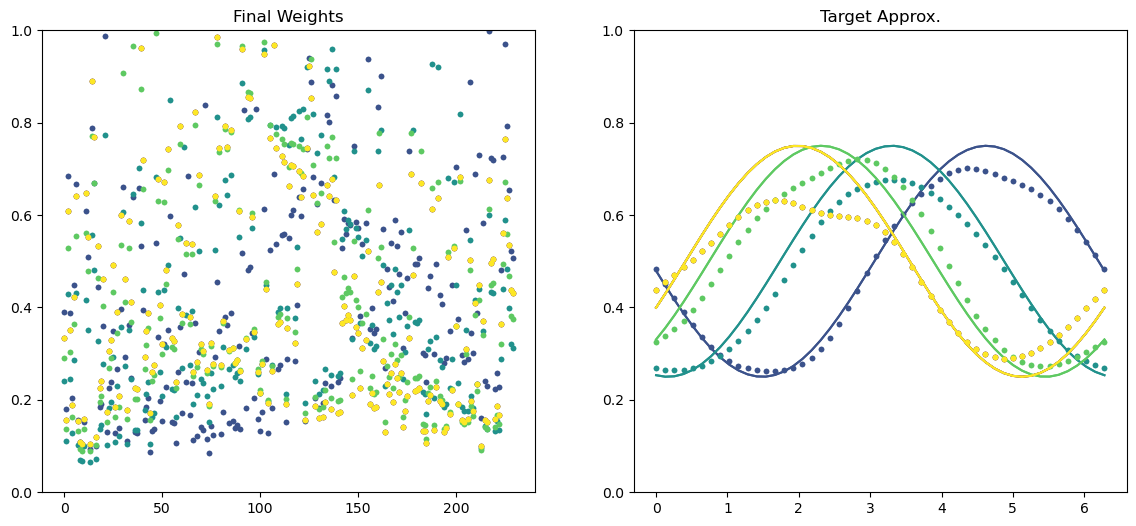

In [117]:
# POST TRAINING ---------------------
final_weights = MultiModel.weights.detach().numpy().squeeze()
new_MultiModel = SwinehartAbbottNetworkOneLayer(input_size, output_size, init_gain, init_shift, final_weights, connect_prob=conProb)
final_outputs = new_MultiModel(xs).detach().numpy().squeeze()

num_units_sample = 5
np.random.seed(42)
samp_inds = np.random.randint(0, output_size-1, num_units_sample) #np.linspace(0, output_size-1, num_units_sample).astype(int)
colors = plt.cm.viridis(np.linspace(0, 1, num_units_sample))  


plt.figure(figsize=(14, 6))
for i, targ_ind in enumerate(samp_inds):
    
    # Weights
    plt.subplot(1,2,1)
    plt.plot(final_weights[targ_ind, :], '.', color=colors[i])
    plt.plot(final_weights[targ_ind, :], '.', color=colors[i])
    plt.title("Final Weights")
    plt.ylim([0, 1])


    # Targ Approx
    plt.subplot(1,2,2)
    plt.plot(xs, target_outputs[targ_ind, :], color=colors[i])
    plt.plot(xs, final_outputs[targ_ind, :], '.', color=colors[i])
    plt.ylim([0, 1])

    plt.plot(xs, target_outputs[targ_ind, :], color=colors[i])
    plt.plot(xs, final_outputs[targ_ind, :], '.', color=colors[i])
    plt.ylim([0, 1])

    plt.title("Target Approx.")



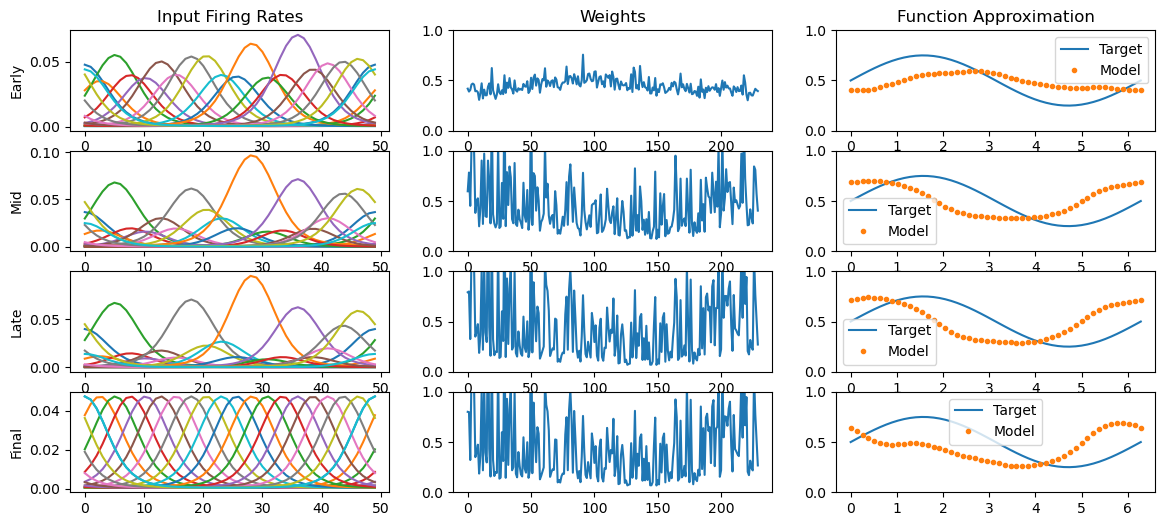

In [104]:
#  set time points to check values
early_ind = int(num_rc_rfs*0.01)
mid_ind = int(num_rc_rfs*0.15)
late_ind = int(num_rc_rfs*0.95)

out_ind = 1
ys = target_output_2

# randomly sample the units
num_units_sample = 20
samp_inds = np.linspace(0, input_size-1, num_units_sample).astype(int)

# EARLY TRAINING ---------------------

plt.figure(figsize=(14, 6))
plt.subplot(4,3,1)
vals = rc_receptive_fields[samp_inds, :, early_ind].T
plt.plot(vals);
#plt.ylim([0, 0.06])
plt.ylabel("Early")
plt.title("Input Firing Rates")

plt.subplot(4,3,2)
plt.plot(rc_rfs_weights[out_ind, :,early_ind]);
plt.ylim([0, 1])
plt.title("Weights")

plt.subplot(4,3,3)
plt.plot(xs, ys, label="Target")
plt.plot(xs, rc_rfs_outputs[out_ind, :,early_ind], '.',label="Model")
plt.title("Function Approximation")
plt.ylim([0, 1])
plt.legend()
 
# MID TRAINING ---------------------

plt.subplot(4,3,4)
vals = rc_receptive_fields[samp_inds, :, mid_ind].T
plt.plot(vals);
#plt.ylim([0, 0.06])
plt.ylabel("Mid")

plt.subplot(4,3,5)
plt.plot(rc_rfs_weights[out_ind, :,mid_ind]);
plt.ylim([0, 1])

plt.subplot(4,3,6)
plt.plot(xs, ys, label="Target")
plt.plot(xs, rc_rfs_outputs[out_ind, :,mid_ind], '.',label="Model")
plt.ylim([0, 1])
plt.legend()

# LATE TRAINING ---------------------

plt.subplot(4,3,7)
vals = rc_receptive_fields[samp_inds, :, late_ind].T
plt.plot(vals);
#plt.ylim([0, 0.06])
plt.ylabel("Late")

plt.subplot(4,3,8)
plt.plot(rc_rfs_weights[out_ind, :,late_ind]);
plt.ylim([0, 1])

plt.subplot(4,3,9)
plt.plot(xs, ys, label="Target")
plt.plot(xs, (rc_rfs_outputs[out_ind,:,late_ind]), '.',label="Model")
plt.ylim([0, 1])
plt.legend()



# POST TRAINING ---------------------
final_weights = MultiModel.weights.detach().numpy().squeeze()
new_MultiModel = SwinehartAbbottNetworkOneLayer(input_size, output_size, init_gain, init_shift, final_weights)
final_outputs = new_MultiModel(xs).detach().numpy().squeeze()
final_rfs = np.zeros((input_size, ndata))

for i, x in enumerate(xs):
    interm_outputs = new_MultiModel(x)
    final_rfs[:, i] = new_MultiModel.hidden_activations.detach().numpy().squeeze()


plt.subplot(4,3,10)
vals = final_rfs[samp_inds, :].T
plt.plot(vals);
#plt.ylim([0, 0.06])
plt.ylabel("Final")

plt.subplot(4,3,11)
plt.plot(final_weights[out_ind, :]);
plt.ylim([0, 1])

plt.subplot(4,3,12)
plt.plot(xs, ys, label="Target")
plt.plot(xs, final_outputs[out_ind, :], '.',label="Model")
plt.ylim([0, 1])
plt.legend()


ValueError: x and y must have same first dimension, but have shapes torch.Size([50]) and (230,)

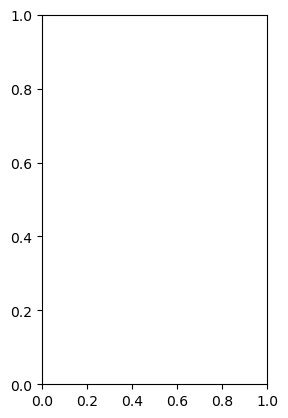

# One Node Param Sweep (takes a while to run)

In [762]:
# Adjustable Params
input_size = 230

num_epochs = 600
controller_lr = 0.8 #0.2
hebbian_lr = 0.03

has_controller = True
has_hebbian = True


# Data Generation, we will generate data points between 0 and 2*pi
ndata = 50
xs = torch.linspace(0, 2 * torch.pi, ndata)
ys = torch.cos(xs)/4 + 0.5
torch.manual_seed(42)


# Things to track
num_gains = num_shifts = 10
all_gains = np.linspace(0, 10, num_gains)
all_shifts = np.linspace(-2, 10, num_shifts)
all_alpha_fracs = [0.1, 0.4, 0.8]
num_alphas = 3
all_losses = np.zeros((num_gains, num_shifts, num_alphas))
all_weights =  np.zeros((num_gains, num_shifts, num_alphas, input_size))
tracker = 0


# Run simulation
for a_ind, a_init in enumerate(all_alpha_fracs):
    for g_ind, g_init in enumerate(all_gains):
        for s_ind, s_init in enumerate(all_shifts):

            init_gain = g_init * np.ones((input_size, 1))
            init_shift = s_init * np.ones((input_size, 1))
            hebb_alpha = int(input_size * a_init) 

            init_weight = np.ones((1, input_size)) 
            init_weight /= np.sum(init_weight) 
            init_weight *= hebb_alpha

            model = SwinehartAbbottNetworkOneLayer(input_size, init_gain, init_shift, init_weight)
            loss_func = nn.MSELoss()
            optimizer = optim.SGD([model.gain, model.shift], lr=controller_lr)



            for epoch in range(num_epochs):

                # shuffle data
                perm_idx = np.arange(ndata) #torch.randperm(ndata)
                shuffled_xs = xs[perm_idx]
                shuffled_ys = ys[perm_idx]

                epoch_loss = 0

                # forward
                for x, y in zip(shuffled_xs, shuffled_ys):     

                    # forward   
                    actv_opl = model(x)
                    output = actv_opl.squeeze()

                    # Calculate loss
                    loss = 0.5 * loss_func(output, y)
                    epoch_loss += loss

                    # backprop for gains and shifts
                    if has_controller:

                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()


                    # hebbian learning for weights
                    if has_hebbian:

                        hebbian_update = model.output_activations * (model.hidden_activations).T
                        with torch.no_grad():
                            model.weights += hebbian_lr * hebbian_update
                            model.weights /= torch.sum(model.weights) 
                            model.weights *= hebb_alpha


                epoch_loss /= ndata
            
            all_losses[g_ind, s_ind, a_ind] = epoch_loss
            all_weights[g_ind, s_ind, a_ind, :] = model.weights.detach().numpy().squeeze()
            tracker+=1
            print(f"Done with {tracker} of {num_gains*num_shifts*3} simulations. Alpha: {a_init}, Gain: {g_init}, Shift: {s_init}, Final Loss: {epoch_loss}")



Done with 1 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: -2.0, Final Loss: 0.13843750953674316
Done with 2 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: -0.6666666666666667, Final Loss: 0.13843750953674316
Done with 3 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: 0.6666666666666665, Final Loss: 0.13843750953674316
Done with 4 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: 2.0, Final Loss: 0.13843750953674316
Done with 5 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: 3.333333333333333, Final Loss: 0.13843750953674316
Done with 6 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: 4.666666666666666, Final Loss: 0.13843750953674316
Done with 7 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: 6.0, Final Loss: 0.13843750953674316
Done with 8 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: 7.333333333333332, Final Loss: 0.13843750953674316
Done with 9 of 300 simulations. Alpha: 0.1, Gain: 0.0, Shift: 8.666666666666666, Final Loss: 0.13843750953674316
Done with 10 of 300 s

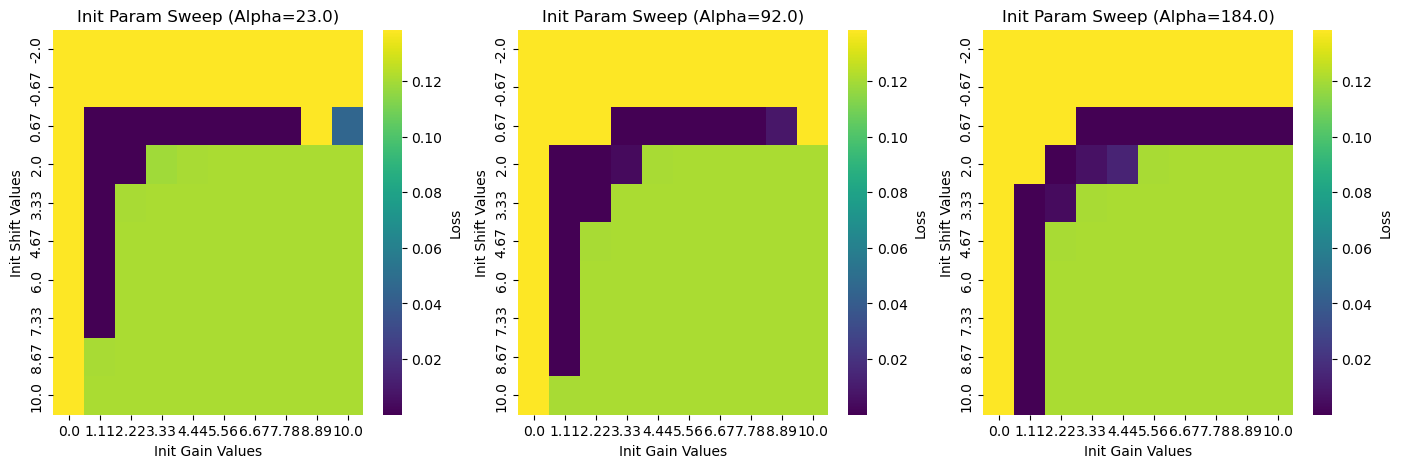

In [769]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming matrix, xvals, and yvals are already defined
plt.figure(figsize=(17, 5))

alphaInd = 0 
plt.subplot(1,3,1)
heatmap = sns.heatmap(all_losses[:,:,alphaInd].T, xticklabels=np.round(all_gains, 2), yticklabels=np.round(all_shifts, 2), cmap='viridis')
plt.xlabel('Init Gain Values')
plt.ylabel('Init Shift Values')
plt.title(f'Init Param Sweep (Alpha={input_size*all_alpha_fracs[alphaInd]})')
cbar = heatmap.collections[0].colorbar
cbar.set_label('Loss')
#plt.show()


alphaInd = 1 
plt.subplot(1,3,2)
heatmap = sns.heatmap(all_losses[:,:,alphaInd].T, xticklabels=np.round(all_gains, 2), yticklabels=np.round(all_shifts, 2), cmap='viridis')
plt.xlabel('Init Gain Values')
plt.ylabel('Init Shift Values')
plt.title(f'Init Param Sweep (Alpha={input_size*all_alpha_fracs[alphaInd]})')
cbar = heatmap.collections[0].colorbar
cbar.set_label('Loss')
#plt.show()


alphaInd = 2 
plt.subplot(1,3,3)
heatmap = sns.heatmap(all_losses[:,:,alphaInd].T, xticklabels=np.round(all_gains, 2), yticklabels=np.round(all_shifts, 2), cmap='viridis')
plt.xlabel('Init Gain Values')
plt.ylabel('Init Shift Values')
plt.title(f'Init Param Sweep (Alpha={input_size*all_alpha_fracs[alphaInd]})')
cbar = heatmap.collections[0].colorbar
cbar.set_label('Loss')
#plt.show()



In [748]:
all_losses[6, 2], all_gains[6], all_shifts[2]

(0.0033010286279022694, 6.666666666666667, 0.6666666666666665)